In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from itertools import product
plt.style.use("seaborn-v0_8")

In [2]:
prices_raw_2 = pd.read_csv("prices_round_5_day_2.csv", sep = ";", index_col = "timestamp")
prices_raw_3 = pd.read_csv("prices_round_5_day_3.csv", sep = ";", index_col = "timestamp")
prices_raw_4 = pd.read_csv("prices_round_5_day_4.csv", sep = ";", index_col = "timestamp")
prices_raw_3.index = prices_raw_3.index + prices_raw_2.index.max() + 100
prices_raw_4.index = prices_raw_4.index + prices_raw_3.index.max() + 100
prices_raw = pd.concat([prices_raw_2, prices_raw_3, prices_raw_4], axis=0)
mid_prices = prices_raw[["product", "mid_price"]]
mid_prices = (
    mid_prices.reset_index()  # makes timestamp a normal column (usually named "timestamp")
       .pivot(index="timestamp", columns="product", values="mid_price")
       .sort_index()
)
pebble = mid_prices.filter(regex=r'^PEBBLES')

In [3]:
log_prices = np.log(pebble)
xs = log_prices["PEBBLES_XS"]
s = log_prices["PEBBLES_S"]
m = log_prices["PEBBLES_M"]
l = log_prices["PEBBLES_L"]
xl = log_prices["PEBBLES_XL"]
y5 = np.column_stack([xs, s, m, l, xl])

In [4]:
from statsmodels.tsa.vector_ar.vecm import coint_johansen

result = coint_johansen(y5, 0, 10)
print("Trace Statistic: \n", result.lr1)
print("Trace Critical Values: \n", result.cvt)
print("Max Eigenvalue Statistic: \n", result.lr2)
print("Max Eigenvalue Critical Values: \n", result.cvm)

Trace Statistic: 
 [48.34396734 26.63486035 15.06052543  7.62262696  2.74093172]
Trace Critical Values: 
 [[65.8202 69.8189 77.8202]
 [44.4929 47.8545 54.6815]
 [27.0669 29.7961 35.4628]
 [13.4294 15.4943 19.9349]
 [ 2.7055  3.8415  6.6349]]
Max Eigenvalue Statistic: 
 [21.70910698 11.57433492  7.43789847  4.88169524  2.74093172]
Max Eigenvalue Critical Values: 
 [[31.2379 33.8777 39.3693]
 [25.1236 27.5858 32.7172]
 [18.8928 21.1314 25.865 ]
 [12.2971 14.2639 18.52  ]
 [ 2.7055  3.8415  6.6349]]


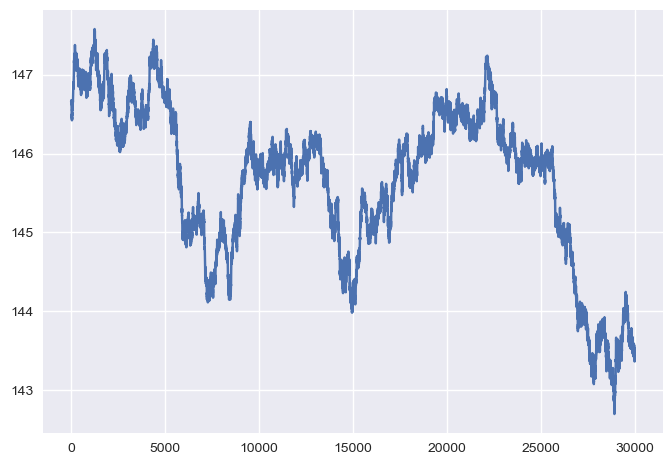

In [5]:
beta = result.evec[:, 4]
spread = y5 @ beta
plt.plot(spread)

In [7]:
result.evec[:, 0]

array([26.70190047,  3.0747526 , 32.10456823, 20.02572565, 28.07569199])

In [8]:
import statsmodels.tsa.stattools as ts
cadf = ts.adfuller(spread)
print ('Augmented Dickey Fuller test statistic =',cadf[0])
print ('Augmented Dickey Fuller p-value =',cadf[1])
print ('Augmented Dickey Fuller 1%, 5% and 10% test statistics =',cadf[4])

Augmented Dickey Fuller test statistic = -1.4150532670949476
Augmented Dickey Fuller p-value = 0.5750384964503747
Augmented Dickey Fuller 1%, 5% and 10% test statistics = {'1%': np.float64(-3.4305680025880942), '5%': np.float64(-2.8616363512511263), '10%': np.float64(-2.5668212848307097)}


In [9]:
spread.mean()

np.float64(145.65424012842163)

In [10]:
spread.std()

np.float64(1.0012244041128462)